# Introduction: What can Python do for economists?

**Programming for Economists, Autumn 2026**

This notebook is the live-coding part of Lecture 1. It is a guided tour, not a test. You are **not expected to understand every line of code today**.

Focus on the basic workflow:

1. Change an input.
2. Run the cell.
3. Inspect the result.
4. Decide whether the result makes economic sense.

Today, we will use Python to make a calculation, inspect economic data, solve a small market model, and simulate uncertainty.

## Slides and course material

We begin with the existing [Introduction slides](Introduction.pdf). The examples below are the coding part of the lecture.

- [Course website](https://sites.google.com/view/numeconcph-progecon/home)
- [Lecture notebooks](https://github.com/NumEconCopenhagen/ProgEcon-lectures)
- [Exercise notebooks](https://github.com/NumEconCopenhagen/ProgEcon-exercises)

## Contents

1. [Running a notebook](#1.-Running-a-notebook)
2. [A first calculation](#2.-A-first-calculation)
3. [Working with economic data](#3.-Working-with-economic-data)
4. [Solving a market model](#4.-Solving-a-market-model)
5. [Simulating uncertainty](#5.-Simulating-uncertainty)
6. [After today](#6.-After-today)

## 1. Running a notebook

Open the **lecture folder** in VS Code, rather than opening only this file. Files ending in `.ipynb` are Jupyter notebooks. Files ending in `.py` contain Python code.

A notebook contains:

- **Markdown cells** with text and equations.
- **Code cells** that Python can run.

Useful commands:

- <kbd>Shift</kbd>+<kbd>Enter</kbd>: run the current cell and move to the next one.
- <kbd>Ctrl</kbd>+<kbd>Enter</kbd>: run the current cell and stay there.
- **Restart and Run All**: run the notebook again from the beginning.

Run notebooks from top to bottom. Python remembers variables created in earlier cells.

Run the cell below. If it prints a message, the notebook is connected to Python.

In [1]:
course = "Programming for Economists"
print(f"{course}: Python is running.")

Programming for Economists: Python is running.


> **Try it:** Change the text inside the quotation marks and run the cell again.

## 2. A first calculation

Suppose you deposit 10,000 DKK in an account that pays 4 percent interest per year. With compound interest, savings after $T$ years are

$$
A_T = A_0(1+r)^T.
$$

Python can evaluate the formula immediately.

In [2]:
initial_savings = 10_000
interest_rate = 0.04
years = 5

future_savings = initial_savings * (1 + interest_rate)**years

print(f"Savings after {years} years: {future_savings:,.0f} DKK")

Savings after 5 years: 12,167 DKK


> **Try it:** Change the interest rate from `0.04` to `0.02`, or change the number of years. Run the cell again and compare the result.

The names `initial_savings`, `interest_rate`, and `years` are **variables**. Variables let us change assumptions without rewriting the calculation.

## 3. Working with economic data

Later in the course, we will download, clean, combine, and visualize much larger datasets. Here, we use a small extract of employment-rate data for three Danish municipalities.

*Source: Statistics Denmark, table RAS200, selected observations from the course data files.*

First, we import three packages used throughout the course:

- `numpy` for numerical calculations.
- `pandas` for data.
- `matplotlib` for figures.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

A `DataFrame` is a table with rows and columns.

In [4]:
employment_rates = pd.DataFrame({
    "year": [2018, 2019, 2020, 2021, 2022, 2023],
    "Copenhagen": [73.2, 73.9, 72.8, 76.1, 76.7, 76.8],
    "Aarhus": [70.5, 71.1, 70.5, 73.7, 74.3, 74.2],
    "Aalborg": [71.0, 71.4, 71.0, 74.3, 75.2, 75.5],
}).set_index("year")

employment_rates

,Copenhagen,Aarhus,Aalborg
year,,,
2018,73.2,70.5,71.0
2019,73.9,71.1,71.4
2020,72.8,70.5,71.0
2021,76.1,73.7,74.3
2022,76.7,74.3,75.2
2023,76.8,74.2,75.5


The same data can be easier to understand in a figure.

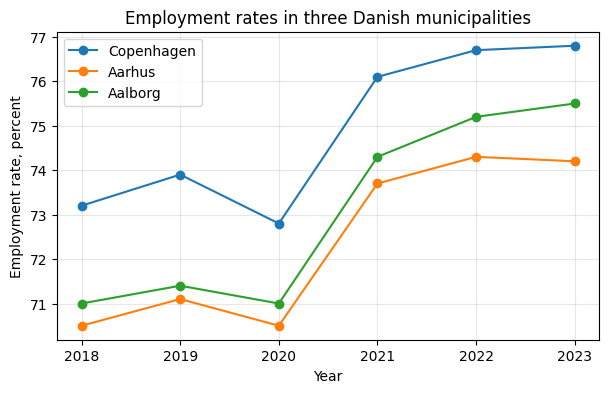

In [5]:
ax = employment_rates.plot(figsize=(7, 4), marker="o")
ax.set_title("Employment rates in three Danish municipalities")
ax.set_xlabel("Year")
ax.set_ylabel("Employment rate, percent")
ax.grid(alpha=0.3)
plt.show()

Python can also answer a specific question. How much did the employment rate change from 2020 to 2023?

In [6]:
change_2020_2023 = employment_rates.loc[2023] - employment_rates.loc[2020]
change_2020_2023.sort_values(ascending=False)

Aalborg       4.5
Copenhagen    4.0
Aarhus        3.7
dtype: float64

> **Try it:** Replace `2020` with `2019`. Which municipality then has the largest increase?

This is the basic data workflow used later in the course: **load data, inspect it, transform it, plot it, and answer an economic question**.

## 4. Solving a market model

Consider a simple market with linear demand and supply:

$$
Q^D(p) = 100 - 2p,
$$

$$
Q^S(p) = 10 + 3p.
$$

The equilibrium price makes demand and supply equal. We let Python search over many possible prices and select the price with the smallest market imbalance.

In [7]:
demand_intercept = 100
demand_slope = 2
supply_intercept = 10
supply_slope = 3

price_grid = np.linspace(0, 40, 401)
quantity_demanded = demand_intercept - demand_slope * price_grid
quantity_supplied = supply_intercept + supply_slope * price_grid

market_gap = np.abs(quantity_demanded - quantity_supplied)
equilibrium_index = np.argmin(market_gap)

equilibrium_price = price_grid[equilibrium_index]
equilibrium_quantity = quantity_demanded[equilibrium_index]

print(f"Equilibrium price: {equilibrium_price:.1f}")
print(f"Equilibrium quantity: {equilibrium_quantity:.1f}")

Equilibrium price: 18.0
Equilibrium quantity: 64.0


A figure makes the economic result visible.

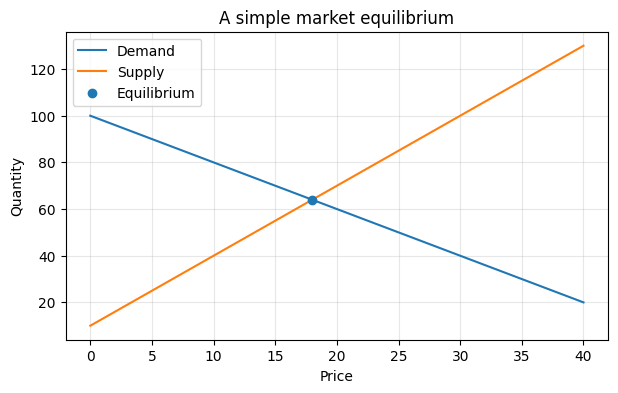

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(price_grid, quantity_demanded, label="Demand")
ax.plot(price_grid, quantity_supplied, label="Supply")
ax.scatter(equilibrium_price, equilibrium_quantity, zorder=3, label="Equilibrium")

ax.set_title("A simple market equilibrium")
ax.set_xlabel("Price")
ax.set_ylabel("Quantity")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

> **Try it:** Change `demand_intercept` from `100` to `115`, then rerun the two code cells in this section. What happens to the equilibrium price and quantity?

Later, we will use the same logic for optimization, root-finding, the Solow model, and an exchange economy.

## 5. Simulating uncertainty

Economic outcomes are uncertain. Suppose the demand intercept is normally distributed around its baseline value. With one command, Python can draw demand conditions for 1,000 hypothetical markets.

The number `123` is a **seed**. It ensures that everyone gets the same random numbers when the cell is rerun.

In [9]:
rng = np.random.default_rng(123)

simulated_demand_intercepts = rng.normal(
    loc=demand_intercept,
    scale=8,
    size=1_000,
)

simulated_equilibrium_prices = (
    simulated_demand_intercepts - supply_intercept
) / (demand_slope + supply_slope)

lower_price, upper_price = np.quantile(simulated_equilibrium_prices, [0.05, 0.95])

print(f"Average equilibrium price: {simulated_equilibrium_prices.mean():.2f}")
print(f"Middle 90 percent: {lower_price:.2f} to {upper_price:.2f}")

Average equilibrium price: 18.04
Middle 90 percent: 15.29 to 20.50


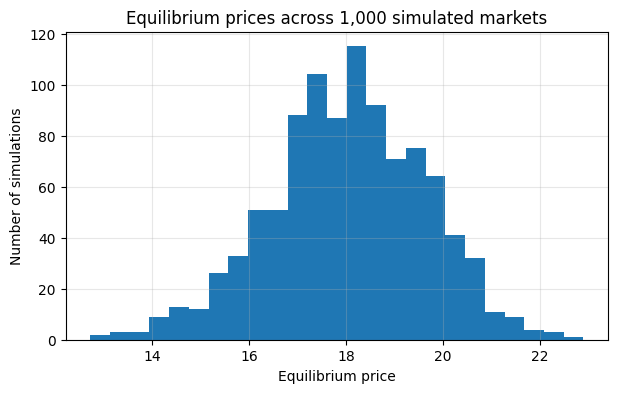

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(simulated_equilibrium_prices, bins=25)
ax.set_title("Equilibrium prices across 1,000 simulated markets")
ax.set_xlabel("Equilibrium price")
ax.set_ylabel("Number of simulations")
ax.grid(alpha=0.3)
plt.show()

The code above combines several parts of the course:

- **Python basics** to state assumptions and calculations.
- **NumPy** to work with many numbers at once.
- **Plotting** to communicate results.
- **Numerical methods** to solve a model.
- **Random numbers** to study uncertainty.

The later lectures explain each ingredient carefully. The projects combine them to answer larger economic questions.

## 6. After today

Before the next in-person lecture:

1. Make sure your Python installation and course folders work.
2. Work on **Problem Set 0: Getting Started**.
3. Complete Chapters 1–2 of **Introduction to Python** on DataCamp by **Sunday, September 13 at 23:59**.

There is no in-person lecture on **Wednesday, September 9**. Use that week for setup, Problem Set 0, and DataCamp. The next in-person lecture is **Python Basics I on Wednesday, September 16**.